Due: Thu Feb 5 (technically Feb 6 at 2 AM)

# ODEs : N-body dynamics

In an N-body problem, body "0" at position $\mathbf r_0$ will experience a vector acceleration $\mathbf a_1$ due to forces from another body "1" at position $\mathbf r_1$.

If there are multiple bodies, we add the accelerations from all other bodies $1\ldots N-1$ vectorially as follows
$$
\mathbf{a} = \sum_{i=1}^{N-1} \mathbf{a}_i
$$

As we have seen in class, there are several different methods to integrate the equations of motion. These will be explored in this assignment.


#### Application: Lennard-Jones forces

Specifically we will use the Lennard-Jones potential,
$$
V_\text{LJ}(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]
$$
with parameters suitable for Argon atoms. See lecture notebook 3f for the details.


#### Implementation

Write your code using natural units (of time, length etc) as described in Lecture notebook 3f. You may set the Lennard-Jones force zero for particle pairs with a separation greater than 3.

Your code should allow the option of Euler, RK2 and RK4 methods for an arbitrary number ($N$) of bodies, given an initial position and velocity for each body.

_Try to write the code in a general way so that only the minimum changes need to be made to run using a different method, a different time step, or even a different force law._

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

class Particle(object):
    """
    Class storing information about a particle relative to an argon atom consisting of the mass, position, and velocity. 

    Data Attributes:
        mass
        position
        velocity
   
    """
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = np.array(position)
        self.velocity = np.array(velocity)



def alj(i, x):
    """
    Returns the acceleration of a particle under the influnce of the Lennard-Jones potention in terms of natural units for an argon atom.

    parameters:
    i - index in a list of particles
    x - list of particle positions
    """
    afinal = np.zeros(3)
    for j in range(len(x)):
        if (i!= j):
            xvec = (x[i]-x[j]) #Calculate vector distance between target particle and other particle
            
            xmag = np.linalg.norm(xvec)
         
            if xmag >= 3:
                afinal += 0.0      #Set magnitudes great than 3 to 0
            else:
                amag = (-(xmag)**(-14)+0.5*(xmag)**(-8))*(xmag)  #Calculate magnitude of Lennard-Jones potential
                afinal += amag*xvec
    
    return afinal




def pvcopy(particles):
    """
    Takes a list of Particle instances and separates their position and velocity attributes in a list.

    parameters:
    particles - a list of particle instances
    """
    p = [] #positions 
    v = [] #velocities
    for i in list(range(len(particles))):
        
        p.append(particles[i].position)
        v.append(particles[i].velocity)
    
    return [copy.deepcopy(p), copy.deepcopy(v)]

def euler(particles, t, a):
    """
    Calculates the positions and velocities of a number of Particle instances using the Euler method for solving ordinary differential equations.
    
    parameters:
    particles - a list of particle instances
    t - an array of time values in natural units
    a - a function returning the acceleration of an N-body potential force
    """
    pv = pvcopy(particles)
    
    

    p0 = pv[0]   #Initialize the positions
    v0 = pv[1]   #Initialize the velocities

    t0 = t[0]    
    n = len(t)

    pfinal = []
    vfinal = []
    
    

    pfinal.append(copy.deepcopy(p0))
    vfinal.append(copy.deepcopy(v0))

    for i in range(1, n):
        dt = t[i] - t0
        t0 = t[i]
        
        pfora = copy.deepcopy(p0)

        for j in range(len(p0)):
            p0[j] += v0[j]*dt    #Calculate new positions using velocity
           
        for k in range(len(v0)):
            v0[k] += a(k, pfora)*dt   #Calculate new velocities using accelerations

   

        pfinal.append(copy.deepcopy(p0))
        vfinal.append(copy.deepcopy(v0))
       

    return [np.array(pfinal), np.array(vfinal)]

def rk2(particles, t, a): 
    """
    Calculates the positions and velocities of a number of Particle instances using the RK2 method for solving ordinary differential equations.
    
    parameters:
    particles - a list of particle instances
    t - an array of time values in natural units
    a - a function returning the acceleration of an N-body potential force
    """

    pv = pvcopy(particles)
    
    

    p0 = pv[0]   #Initialize the positions
    v0 = pv[1]   #Initialize the velocities
    
    t0 = t[0]
    n = len(t)

    pfinal = []
    vfinal = []
    

    pfinal.append(copy.deepcopy(p0))
    vfinal.append(copy.deepcopy(v0))


    for i in range(1, n):
        dt = t[i] - t0
        t0 = t[i]
        
        pfora = copy.deepcopy(p0)
        
        xk1 = [] #initializing k1, k2
        xk2 = 0

        vk1 = []
        vk2 = 0


        for j in range(len(p0)):
            xk1.append(v0[j]*dt)          #Calculate k1 for the positions
            vk1.append(a(j, pfora)*dt)    #Calculate k1 for the velocities

        ak1 = np.array(xk1)/2+p0          #Create positions used to calculate k2

        for k in range(len(p0)):

            xk2 = (vk1[k]/2+v0[k])*dt     #Calculate k2 for the positions
            vk2 = (a(k, ak1))*dt          #Calculate k2 for the velocities



            p0[k] += xk2
            v0[k] += vk2



        pfinal.append(copy.deepcopy(p0))
        vfinal.append(copy.deepcopy(v0))



    return [pfinal, vfinal]

def rk4(particles, t, a):
    """
    Calculates the positions and velocities of a number of Particle instances using the RK4 method for solving ordinary differential equations.
    
    parameters:
    particles - a list of particle instances
    t - an array of time values in natural units
    a - a function returning the acceleration of an N-body potential force
    """

    pv = pvcopy(particles)
    
    

    p0 = pv[0]       #Initialize the positions
    v0 = pv[1]       #Initialize the velocties
    
    t0 = t[0]
    n = len(t)

    pfinal = []
    vfinal = []
    

    pfinal.append(copy.deepcopy(p0))
    vfinal.append(copy.deepcopy(v0))
    


    for i in range(1, n):
        dt = t[i] - t0
        t0 = t[i]
        
        pfora = copy.deepcopy(p0)
        
        xk1 = [] #initializing k1, k2, k3, k4
        xk2 = []
        xk3 = []
        xk4 = 0

        vk1 = []
        vk2 = []
        vk3 = []
        vk4 = 0


        for j in range(len(p0)):
            xk1.append(v0[j]*dt)               #Calculate k1 for the positions
            vk1.append(a(j, pfora)*dt)         #Calculate k1 for the velocities

        xk1 = np.array(xk1)
        ak1 = xk1/2+p0                         #Create positions used to calculate k2

        for k in range(len(p0)):

            xk2.append((vk1[k]/2+v0[k])*dt)    #Calculate k2 for the positions
            vk2.append((a(k, ak1))*dt)         #Calculate k2 for the velocities

        xk2 = np.array(xk2)
        ak2 = xk2/2+p0                         #Create positions used to calculate k3

        for m in range(len(p0)):

            xk3.append((vk2[m]/2+v0[m])*dt)    #Calculate k3 for the positions
            vk3.append((a(m, ak2))*dt)         #Calculate k3 for the velocities
        
        xk3 = np.array(xk3)
        ak3 = xk3 + p0                         #Create positions used to calculate k4

        for b in range(len(p0)):
            
            xk4 = (vk3[b]+v0[b])*dt            #Calculate k4 for the positions
            vk4 = (a(b, ak3))*dt               #Calculate k4 for the velocities



            p0[b] += 1/6*(xk1[b]+2*xk2[b]+2*xk3[b]+xk4)
            v0[b] += 1/6*(vk1[b]+2*vk2[b]+2*vk3[b]+vk4)



        pfinal.append(copy.deepcopy(p0))
        vfinal.append(copy.deepcopy(v0))



    return [pfinal, vfinal]


### b) Test 1 - Basic Sanity Check

Set a single Argon atom in motion with a velocity of 0.1 in natural units. 

Check that it travels in a straight line with no acceleration by plotting distance versus time.  

It looks nicest if you plot a curve with occasional (say every 1 time unit) circles. See ``markevery`` option of ``matplotlib.pyplot.plot``. Here is an example:

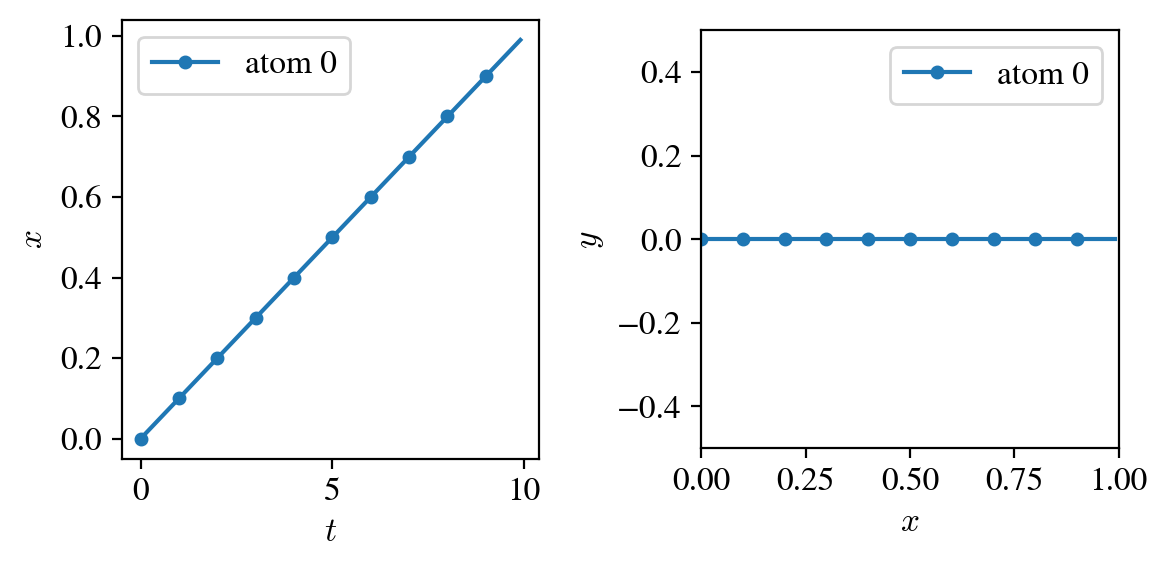

In [2]:
#Data [Postion/velocity] [Time Index] [Particle] [Values]

def xyplotting(particles, t, a, f, ax, timemarker = 1):
    """ 
    Plots the x and y positions of various particles

    parameters:
    particles - a list of Particle instances
    t - an array of time values
    a - a function returning the acceleration of an N-body potential force
    f - a function calling an integration method for solving ordinary differential equations
    ax - a matplotlib.pyplot.subplots axis
    timemarker - the amount of time in natural units between points on a curve (default = 1)
    """
    data = f(particles, t, a)
    atom = 0
    colourlist = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
                  'black', 'lime', 'yellow', 'salmon', 'wheat', 'fuchsia']

    h = t[1]-t[0]
    markevery = 0
    if (h) >= timemarker:              #Calculate how often a circle is marked (every timemarker unit of time)
        markevery = timemarker
    else:
        markevery = int(round(timemarker/(h)))
    
    for i in range(len(data[0][0])):
        xvals = []
        yvals = []
        atom = i
        for j in range(len(data[0])):
            xvals.append(data[0][j][i][0])
            yvals.append(data[0][j][i][1])
        ax.plot(xvals, yvals, 'o', ls = '-', label = f"Atom {atom}", markevery = markevery, color = colourlist[i])


    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"x and y Position of Interacting Argon Atoms in \n Natural Units Using {f.__name__} Method for h = {h:.2f}", fontsize = 10)
    ax.legend(loc = 1, bbox_to_anchor = (1.3, 1))
    


def xtplotting(particles, t, a, f, ax, timemarker = 1):
    """ 
    Plots time vs x position of various particles

    parameters:
    particles - a list of Particle instances
    t - an array of time values
    a - a function returning the acceleration of an N-body potential force
    f - a function calling an integration method for solving ordinary differential equations
    ax - a matplotlib.pyplot.subplots axis
    timemarker - the amount of time in natural units between points on a curve (default = 1)
    """
    data = f(particles, t, a)
    atom = 0

    h = t[1]-t[0]
    markevery = 0
    if (h) >= timemarker:           #Calculate how often a circle is marked (every timemarker unit of time)
        markevery = timemarker
    else:
        markevery = int(round(timemarker/(h)))
    
    for i in range(len(data[0][0])):
        xvals = []
        atom = i
        for j in range(len(data[0])):
            xvals.append(data[0][j][i][0])
        ax.plot(t, xvals, 'o', ls = '-', label = f"Atom {atom}", markevery = markevery)
    

    ax.set_xlabel("t")
    ax.set_ylabel("x")
    ax.set_title(f"x vs t Position of Interacting Argon Atoms in \n Natural Units Using {f.__name__} Method for h = {h:.2f}", fontsize = 10)
    ax.legend(loc = 1, bbox_to_anchor = (1.3, 1))


def vxtplotting(particles, t, a, f, ax, timemarker = 1):
    """ 
    Plots time vs x velocity of various particles

    parameters:
    particles - a list of Particle instances
    t - an array of time values
    a - a function returning the acceleration of an N-body potential force
    f - a function calling an integration method for solving ordinary differential equations
    ax - a matplotlib.pyplot.subplots axis
    timemarker - the amount of time in natural units between points on a curve (default = 1)
    """
    data = f(particles, t, a)
    atom = 0

    h = t[1]-t[0]
    markevery = 0
    if (h) >= timemarker:           #Calculate how often a circle is marked (every timemarker unit of time)
        markevery = timemarker
    else:
        markevery = int(round(timemarker/(h)))
        
    for i in range(len(data[0][0])):
        xvals = []
        atom = i
        for j in range(len(data[0])):
            xvals.append(data[1][j][i][0])
        ax.plot(t, xvals, 'o', ls = '-', label = f"Atom {atom}", markevery = markevery)
    

    ax.set_xlabel("t")
    ax.set_ylabel("$v_x$")
    ax.set_title(f"$v_x$ vs t Position of Interacting Argon Atoms in \n Natural Units Using {f.__name__} Method for h = {h:.2f}", fontsize = 10)
    ax.legend(loc = 1, bbox_to_anchor = (1.3, 1))


def vytplotting(particles, t, a, f, ax, timemarker = 1):
    """ 
    Plots time vs y velocity of various particles

    parameters:
    particles - a list of Particle instances
    t - an array of time values
    a - a function returning the acceleration of an N-body potential force
    f - a function calling an integration method for solving ordinary differential equations
    ax - a matplotlib.pyplot.subplots axis
    timemarker - the amount of time in natural units between points on a curve (default = 1)
    """
    data = f(particles, t, a)
    atom = 0

    h = t[1]-t[0]
    markevery = 0
    if (h) >= timemarker:           #Calculate how often a circle is marked (every timemarker unit of time)
        markevery = timemarker
    else:
        markevery = int(round(timemarker/(h)))
        
    for i in range(len(data[0][0])):
        xvals = []
        atom = i
        for j in range(len(data[0])):
            xvals.append(data[1][j][i][1])
        ax.plot(t, xvals, 'o', ls = '-', label = f"Atom {atom}", markevery = markevery)
    

    ax.set_xlabel("t")
    ax.set_ylabel("$v_y$")
    ax.set_title(f"$v_y$ vs t Position of Interacting Argon Atoms in \n Natural Units Using {f.__name__} Method for h = {h:.2f}", fontsize = 10)
    ax.legend(loc = 1, bbox_to_anchor = (1.3, 1))





<Figure size 640x480 with 0 Axes>

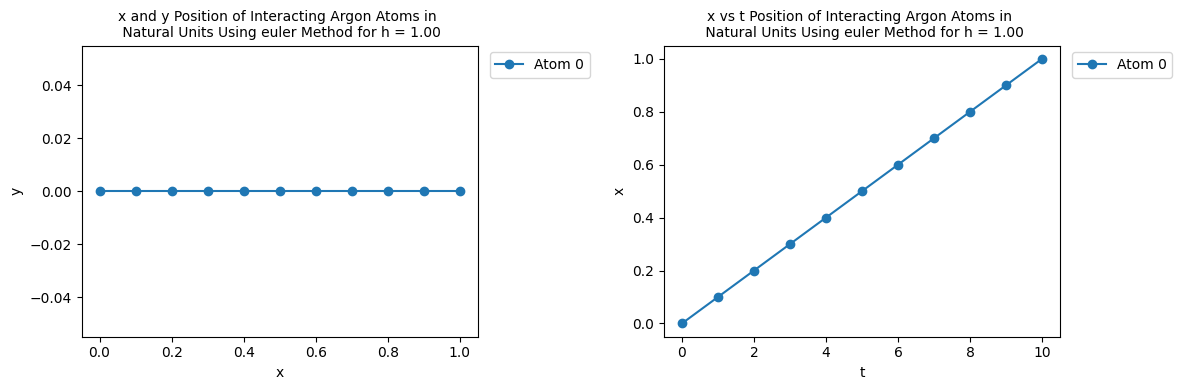

<Figure size 640x480 with 0 Axes>

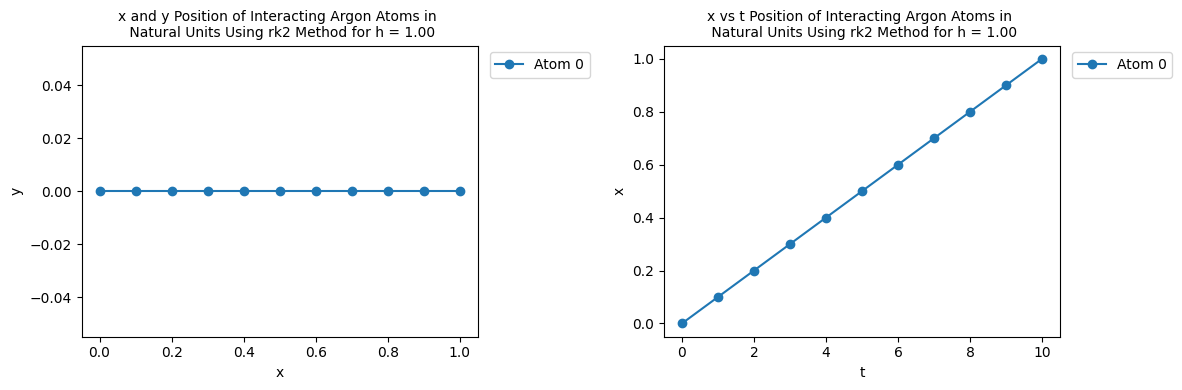

<Figure size 640x480 with 0 Axes>

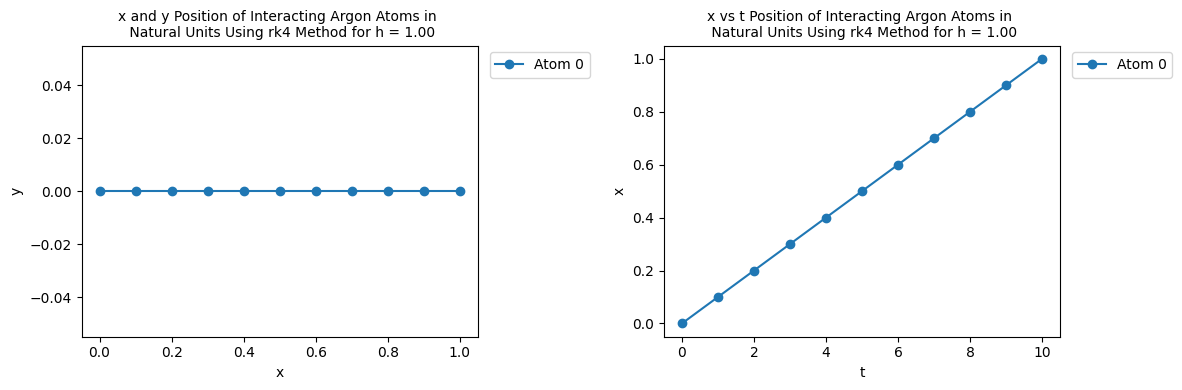

In [3]:
hcheck = 1
tcheck = np.arange(0, 10+hcheck, hcheck)
checkparticle = [Particle(1, [0.0, 0.0, 0.0], [0.1, 0.0, 0.0])]

methods = [euler, rk2, rk4]
for method in methods:
    plt.clf()
    fig, ax = plt.subplots(1, 2, figsize = (12, 4))
    xyplotting(checkparticle, tcheck, alj, method, ax[0])
    xtplotting(checkparticle, tcheck, alj, method, ax[1])
    
    plt.tight_layout()
    plt.show()

### c) Test 2 : Two atom head-on collision

1. Start atom 0 at $(x,y,z) = (-5,0,0)$ with $(v_x, v_y, v_z) = (0.2, 0, 0)$ and another (atom 1) at rest with  $(x,y,z) = (0,0,0)$. Integrate for 40 time units.

2. Plot the trajectories $y$ versus $x$ for both argon atoms on the same plot in different colours. 
Repeat for $x$ versus $t$ and $v_x$ versus $t$.

3. Compare the ratio of the x-component of momentum initially to that at the last timestep. Repeat for kinetic energy.

Do 1-3 by looping over each of the methods Euler, RK2 and RK4, and for each case by looping over the timesteps $h = 1, 0.1, 0.01$ in units of natural time.

Note that you can generate multiple plots from a single cell by calling ``plt.show()`` after each one. Then call ``plt.clf()`` to clear the previous figure if you are then going to show a new plot.

The ratio of the initial momentum to final momentum for euler method at h = 1.00 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for euler method at h = 1.00 is 0.540222


<Figure size 640x480 with 0 Axes>

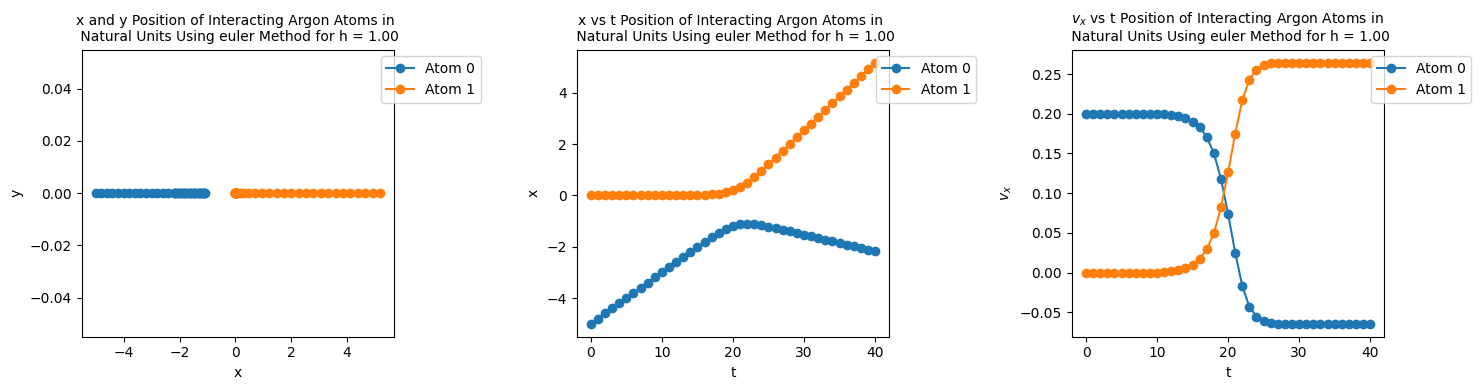

The ratio of the initial momentum to final momentum for euler method at h = 0.10 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for euler method at h = 0.10 is 0.958672


<Figure size 640x480 with 0 Axes>

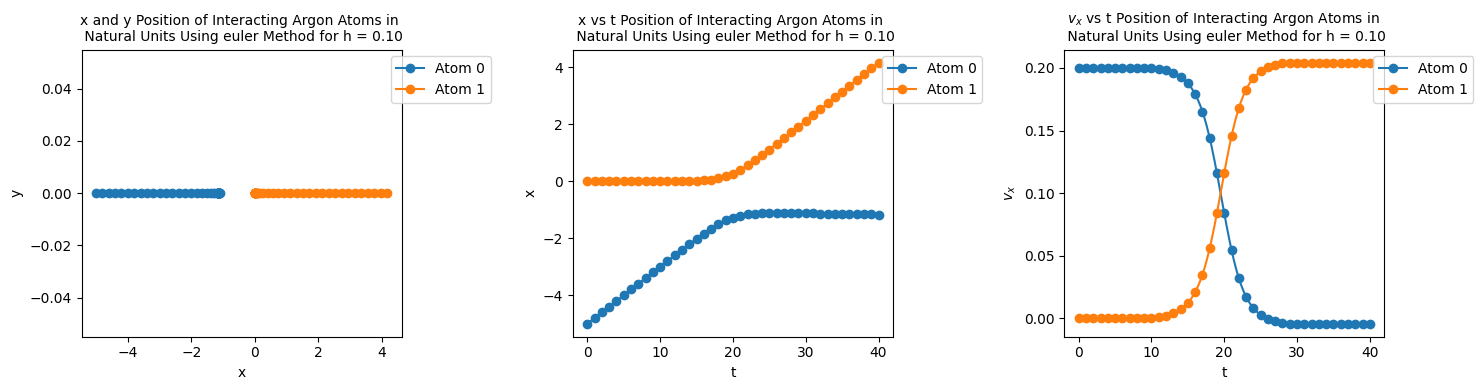

The ratio of the initial momentum to final momentum for euler method at h = 0.01 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for euler method at h = 0.01 is 0.995899


<Figure size 640x480 with 0 Axes>

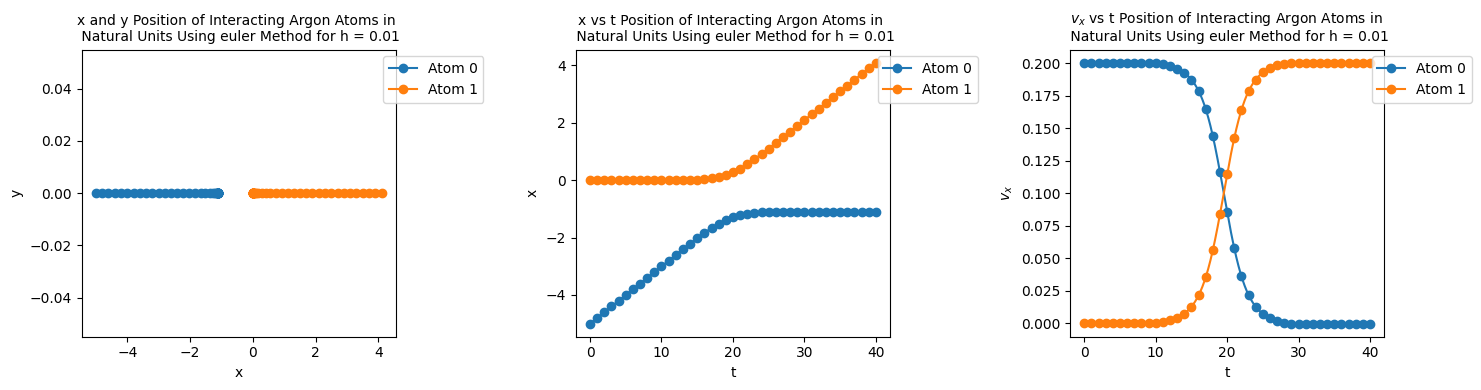

The ratio of the initial momentum to final momentum for rk2 method at h = 1.00 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for rk2 method at h = 1.00 is 0.989002


<Figure size 640x480 with 0 Axes>

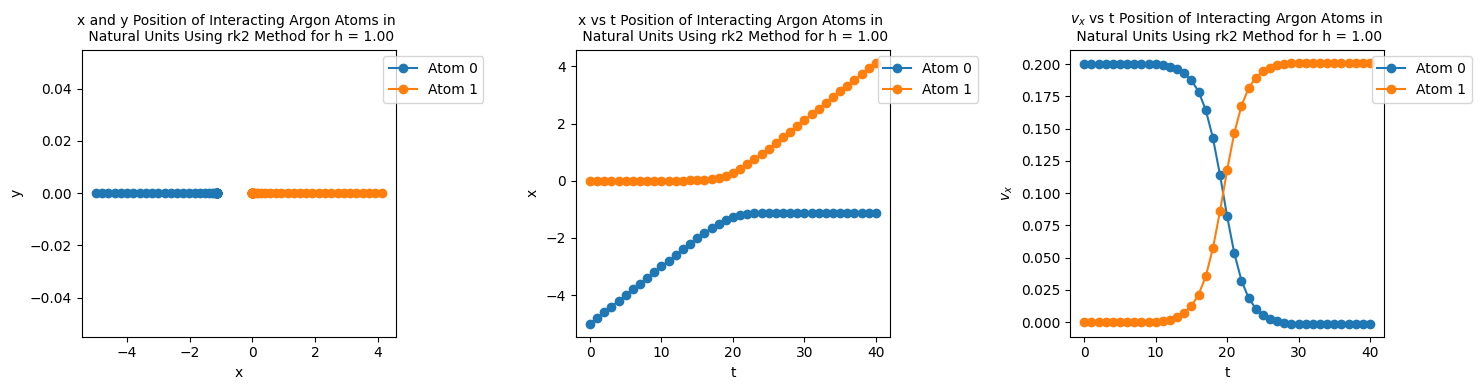

The ratio of the initial momentum to final momentum for rk2 method at h = 0.10 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for rk2 method at h = 0.10 is 0.999693


<Figure size 640x480 with 0 Axes>

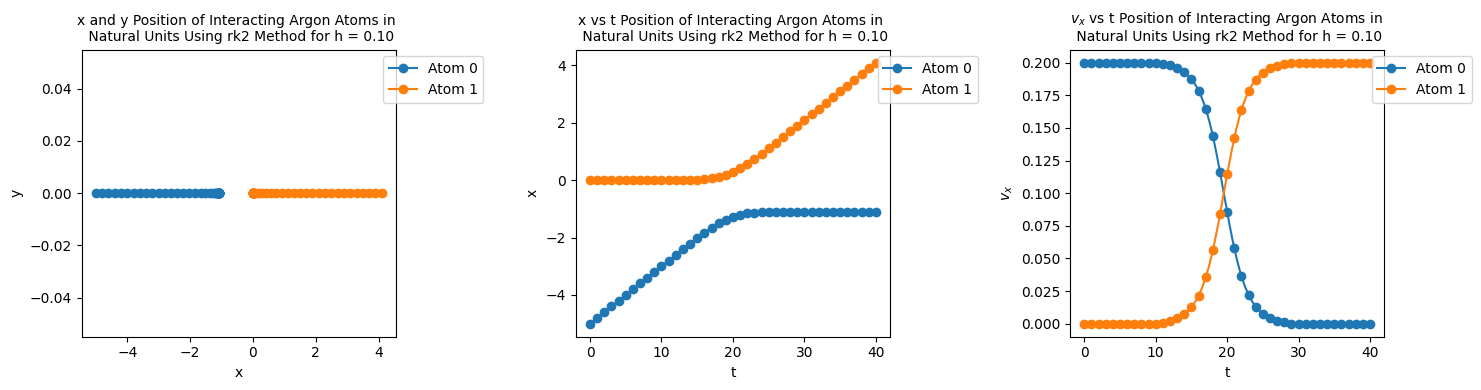

The ratio of the initial momentum to final momentum for rk2 method at h = 0.01 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for rk2 method at h = 0.01 is 0.999989


<Figure size 640x480 with 0 Axes>

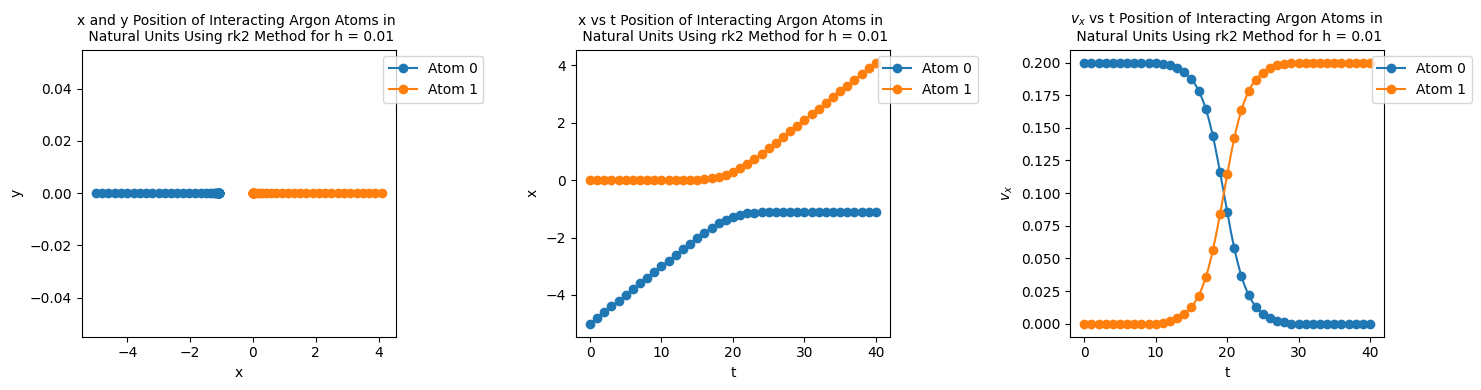

The ratio of the initial momentum to final momentum for rk4 method at h = 1.00 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for rk4 method at h = 1.00 is 1.000548


<Figure size 640x480 with 0 Axes>

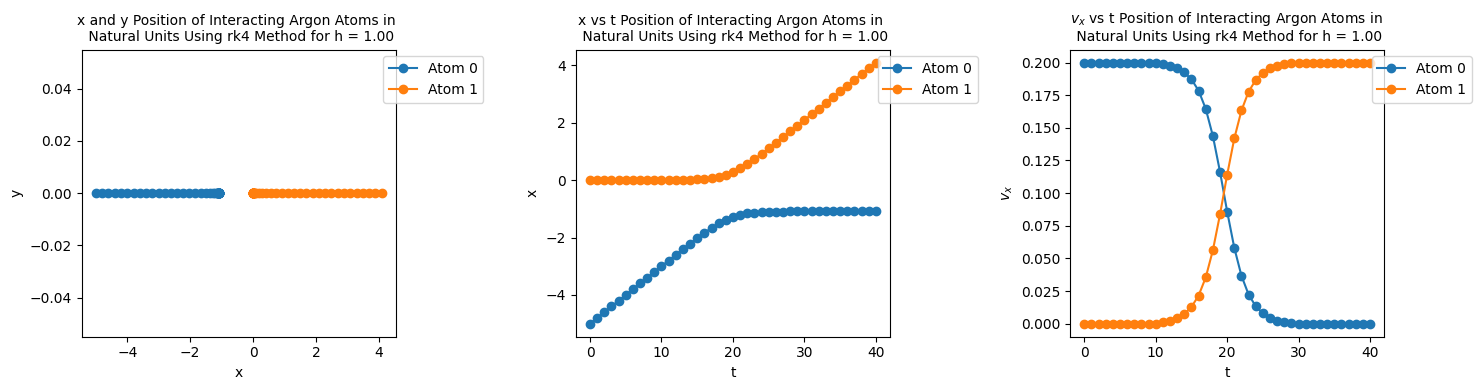

The ratio of the initial momentum to final momentum for rk4 method at h = 0.10 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for rk4 method at h = 0.10 is 0.999706


<Figure size 640x480 with 0 Axes>

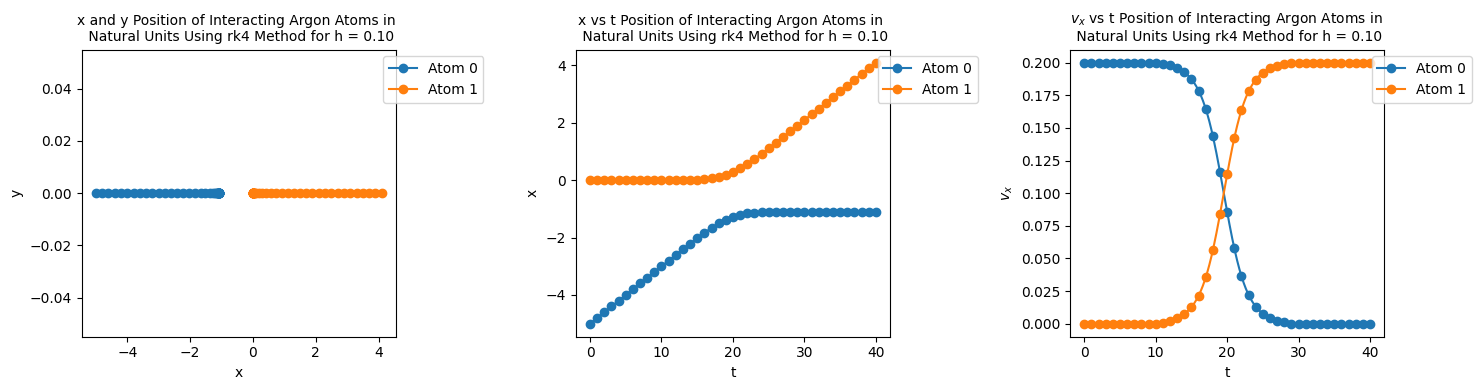

The ratio of the initial momentum to final momentum for rk4 method at h = 0.01 is 1.000000
The ratio of the initial kinetic energy to final kinetic energy for rk4 method at h = 0.01 is 0.999988


<Figure size 640x480 with 0 Axes>

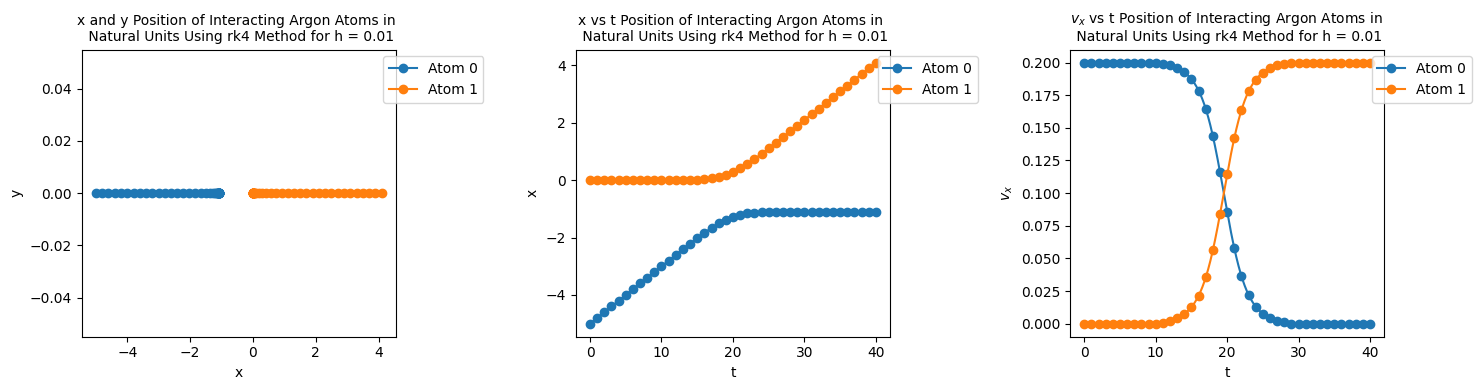

In [4]:
check2particles = [Particle(1, [-5.0, 0.0, 0.0], [0.2, 0.0, 0.0]), Particle(1, [0.0, 0.0, 0.0], [0.0, 0.0, 0.0])]
tmax = 40
hvalues = [1, 0.1, 0.01]
for method in methods:
    for h in hvalues:
        tcheck2 = np.arange(0, tmax + h, h)
        plt.clf()
        fig, ax = plt.subplots(1, 3, figsize = (15, 4))
        xyplotting(check2particles, tcheck2, alj, method, ax[0])
        xtplotting(check2particles, tcheck2, alj, method, ax[1])
        vxtplotting(check2particles, tcheck2, alj, method, ax[2])
        mratio = (method(check2particles, tcheck2, alj)[1][0][0][0]+method(check2particles, tcheck2, alj)[1][0][1][0])/(method(check2particles, tcheck2, alj)[1][-1][0][0]+method(check2particles, tcheck2, alj)[1][-1][1][0])
        eratio = (method(check2particles, tcheck2, alj)[1][0][0][0]**2+method(check2particles, tcheck2, alj)[1][0][1][0]**2)/(method(check2particles, tcheck2, alj)[1][-1][0][0]**2+method(check2particles, tcheck2, alj)[1][-1][1][0]**2)
        print(f"The ratio of the initial momentum to final momentum for {method.__name__} method at h = {h:.2f} is {mratio:.6f}")
        print(f"The ratio of the initial kinetic energy to final kinetic energy for {method.__name__} method at h = {h:.2f} is {eratio:.6f}")

        plt.tight_layout()
        plt.show()


Discuss the relative accuracy of the different methods. 

At large timesteps, all methods do not conserve energy well. Why? And yet they conserve momentum well? Why?  Answer in the markdown cell below.


The smaller timesteps allows for larger approximation error, which will then add up and poorly conserve energy overtime as error adds up. Further, the integration methods do not center around calculating energy itself. However, this is not the case for momentum because the error "cancels" out with both particles since the calculated change in velocity and acceleration is equal and opposite, so the error, regardless of the time step, cancels. These methods do center around calculating momentum (acceleration and velocities are related to momentum), so it is better conserved.

### c) Test 3 : Two-atom offset collision

Now repeat the above steps 1-2 but with some modifications

1. Start atom 0 at $(x,y,z) = (-5,\mathbf{1},0)$ with $(v_x, v_y, v_z) = (0.2, 0, 0)$ and another (atom 1) at rest with  $(x,y,z) = (0,0,0)$. Integrate for 40 time units.

2. Plot the trajectories $y$ versus $x$ for both argon atoms on the same plot in different colours. 
Repeat for $x$ versus $t$, $v_x$ versus $t$ **and $v_y$ versus $t$**.


Use RK4 and a timestep of 0.01

<Figure size 640x480 with 0 Axes>

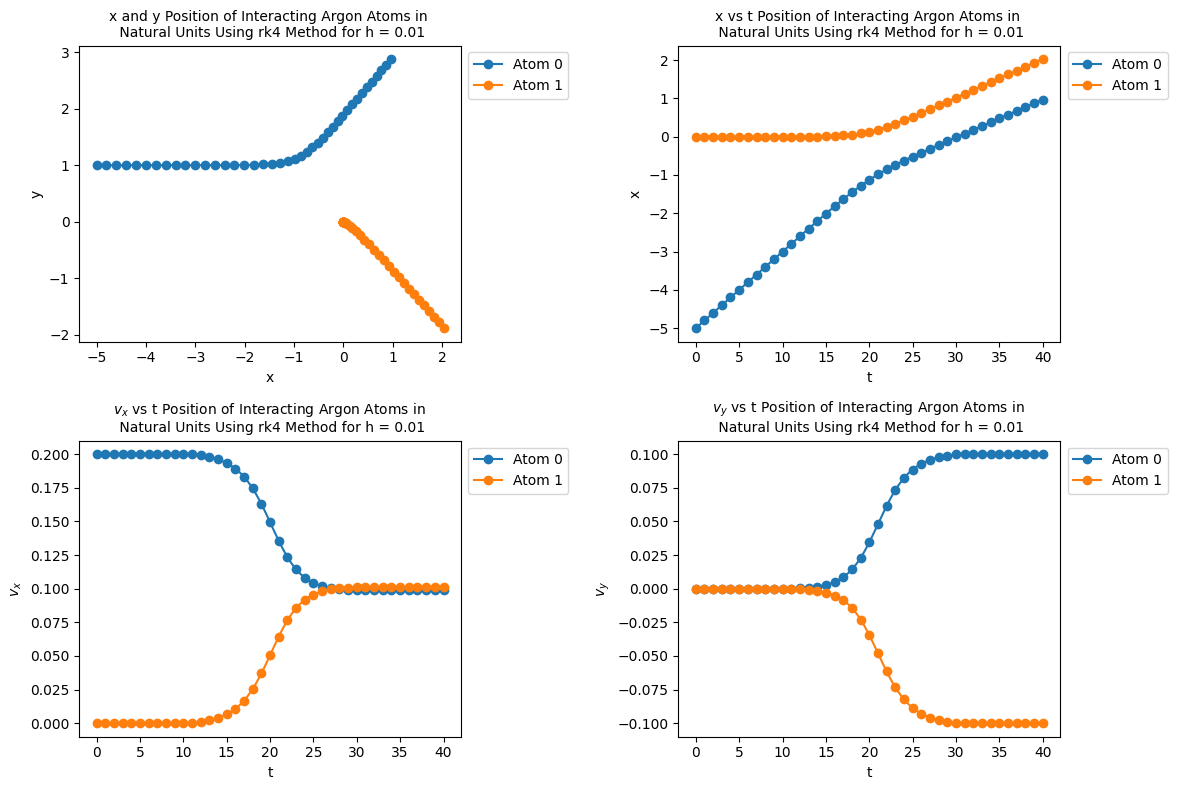

In [ ]:
check3particles = [Particle(1, [-5.0, 1.0, 0.0], [0.2, 0.0, 0.0]), Particle(1, [0.0, 0.0, 0.0], [0.0, 0.0, 0.0])]
tcheck3 = np.arange(0, tmax + 0.01, 0.01)

plt.clf()
fig, axc = plt.subplots(2, 2, figsize = (12, 8))
xyplotting(check3particles, tcheck3, alj, rk4, axc[0, 0])
xtplotting(check3particles, tcheck3, alj, rk4, axc[0, 1])
vxtplotting(check3particles, tcheck3, alj, rk4, axc[1, 0])
vytplotting(check3particles, tcheck3, alj, rk4, axc[1, 1])

plt.tight_layout()
plt.show()

Repeat the previous experiment but with an initial $y$ value of 2 for the atom 0. 

<Figure size 640x480 with 0 Axes>

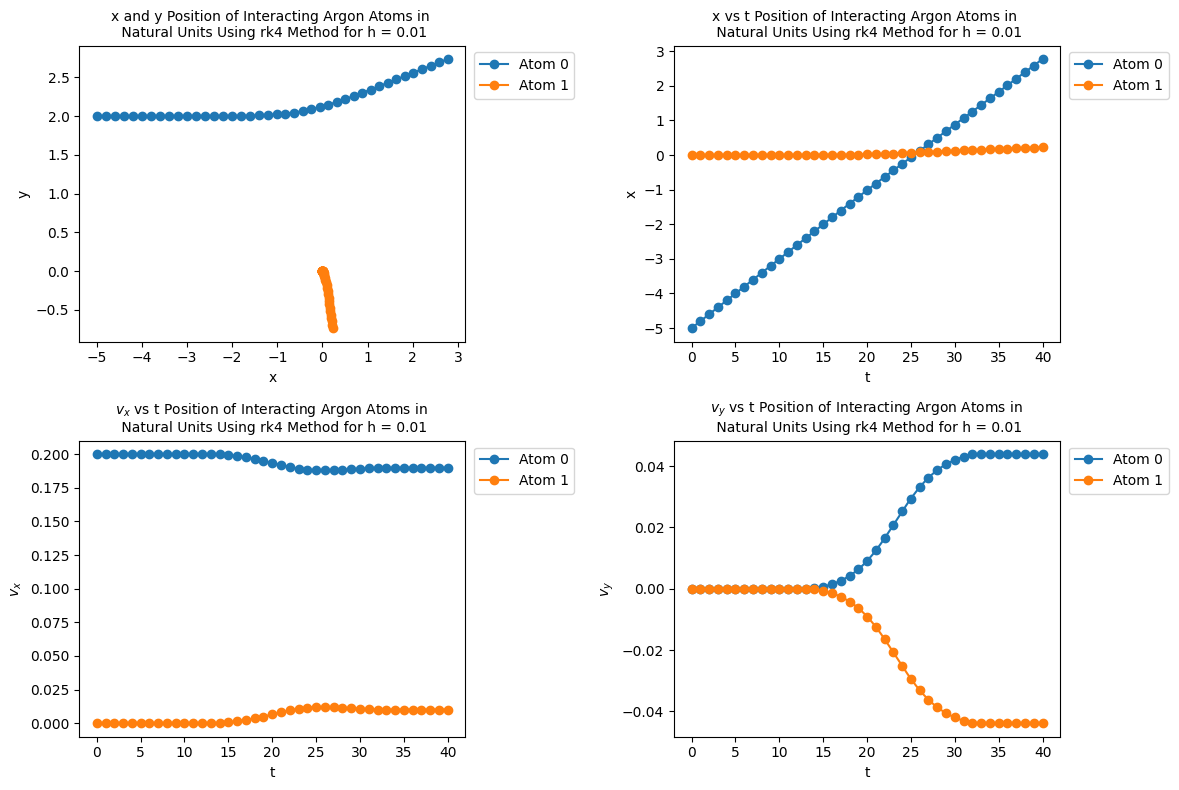

In [ ]:
check4particles = [Particle(1, [-5.0, 2.0, 0.0], [0.2, 0.0, 0.0]), Particle(1, [0.0, 0.0, 0.0], [0.0, 0.0, 0.0])]
tcheck4 = np.arange(0, tmax + 0.01, 0.01)

plt.clf()
fig, axc2 = plt.subplots(2, 2, figsize = (12, 8))
xyplotting(check4particles, tcheck4, alj, rk4, axc2[0, 0])
xtplotting(check4particles, tcheck4, alj, rk4, axc2[0, 1])
vxtplotting(check4particles, tcheck4, alj, rk4, axc2[1, 0])
vytplotting(check4particles, tcheck4, alj, rk4, axc2[1, 1])


plt.tight_layout()
plt.show()

There is qualitively different behaviour of the two particles in the collision when we compare these two cases with different initial $y$ offsets. Why? Discuss in the markdown cell below.

In the y = 1 case, both particles end up with roughly the same $v_x$ and $v_y$ values (roughly equal in magnitude and opposite in direction), whereas in the y = 2 case, this is only true for $v_y$. The difference comes from the height difference. In the y = 2 case, the horizontal (x) component is much smaller than in the y = 1 case, so it acts less on each particle and only slightly changes each particle's speed before they move out of range. 

### d) Test 4 : Argon Pool Break 

Arrange 15 Argon atoms as in a triangular rack for [eight-ball pool](https://en.wikipedia.org/wiki/Eight-ball) with hexagonal packing. The separation between any two adjacent balls is $(2)^{1/6}$ in natural units. Align the plane of the track with the $x-y$ plane so that all balls have $z = 0$.  The front (apex) ball at $(x,y) = (0,0)$ and the two back corners at $(x,y) = (4\cos(30) \times 2^{1/6}, \pm 2\times 2^{1/6}$ ).

Fire the atom 0 (the "cue ball") from $x=-5, y=0, z=0$ in the positive $x$-direction (along the $y=z=0$ axis) with various speeds as described below.

Plot the curves showing trajectories of all the balls (each ball in a different colour) for a duration of 50 with timesteps of 0.1 showing with filled circles every 10 units (100 steps).

Adjust the plots $x$ and $y$ range as appropriate for each case (but maintain the correct aspect ratio so that a 45 degree line looks like 45 degrees when plotted).

Case 1 (Soft Break) :  $v_x = 0.2$

Text(0.5, 1.0, 'Argon Pool Break for $v_x$ = 0.2, Calculated Using RK4 With h = 0.1')

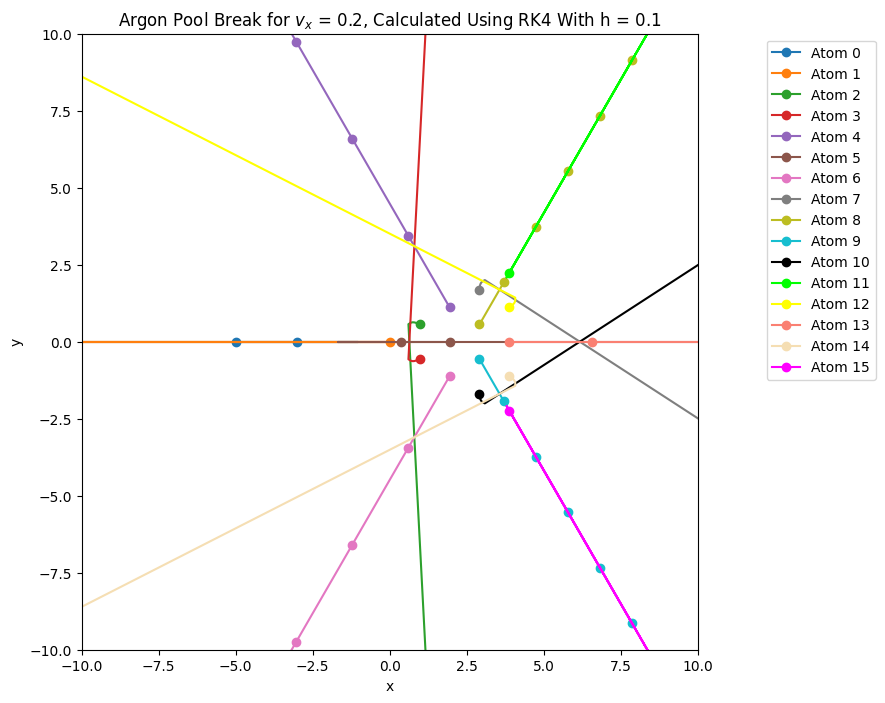

In [7]:
xsep = 2**(1/6)*np.cos(np.radians(30))
ysep = 2**(1/6) #*np.sin(np.radians(30))
cball1 = Particle(1, [-5.0, 0.0, 0.0], [0.2, 0.0, 0.0])
b1 = Particle(1, [0.0, 0.0, 0.0], [0.0, 0.0, 0.0])
b2 = Particle(1, [xsep, 1/2*ysep, 0.0], [0.0, 0.0, 0.0])
b3 = Particle(1, [xsep, -1/2*ysep, 0.0], [0.0, 0.0, 0.0])
b4 = Particle(1, [2*xsep, ysep, 0.0], [0.0, 0.0, 0.0])
b5 = Particle(1, [2*xsep, 0.0, 0.0], [0.0, 0.0, 0.0])
b6 = Particle(1, [2*xsep, -ysep, 0.0], [0.0, 0.0, 0.0])
b7 = Particle(1, [3*xsep, 3/2*ysep, 0.0], [0.0, 0.0, 0.0])
b8 = Particle(1, [3*xsep, 1/2*ysep, 0.0], [0.0, 0.0, 0.0])
b9 = Particle(1, [3*xsep, -1/2*ysep, 0.0], [0.0, 0.0, 0.0])
b10 = Particle(1, [3*xsep, -3/2*ysep, 0.0], [0.0, 0.0, 0.0])
b11 = Particle(1, [4*xsep, 2*ysep, 0.0], [0.0, 0.0, 0.0])
b12 = Particle(1, [4*xsep, ysep, 0.0], [0.0, 0.0, 0.0])
b13 = Particle(1, [4*xsep, 0.0, 0.0], [0.0, 0.0, 0.0])
b14 = Particle(1, [4*xsep, -ysep, 0.0], [0.0, 0.0, 0.0])
b15 = Particle(1, [4*xsep, -2*ysep, 0.0], [0.0, 0.0, 0.0])

pool1 = [cball1, b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, b14, b15]
hpool = 0.1
pooltime = np.arange(0, 50+hpool, hpool)
fig, axpool1 = plt.subplots(1, 1, figsize = (8, 8))
xyplotting(pool1, pooltime, alj, rk4, axpool1, 10)
axpool1.set_xlim(-10, 10)
axpool1.set_ylim(-10, 10)
axpool1.set_box_aspect(1)
axpool1.set_title("Argon Pool Break for $v_x$ = 0.2, Calculated Using RK4 With h = 0.1")

Repeat for case 2 (Firm Break) :  $v_x = 2$

Text(0.5, 1.0, 'Argon Pool Break for $v_x$ = 2.0, Calculated Using RK4 With h = 0.1')

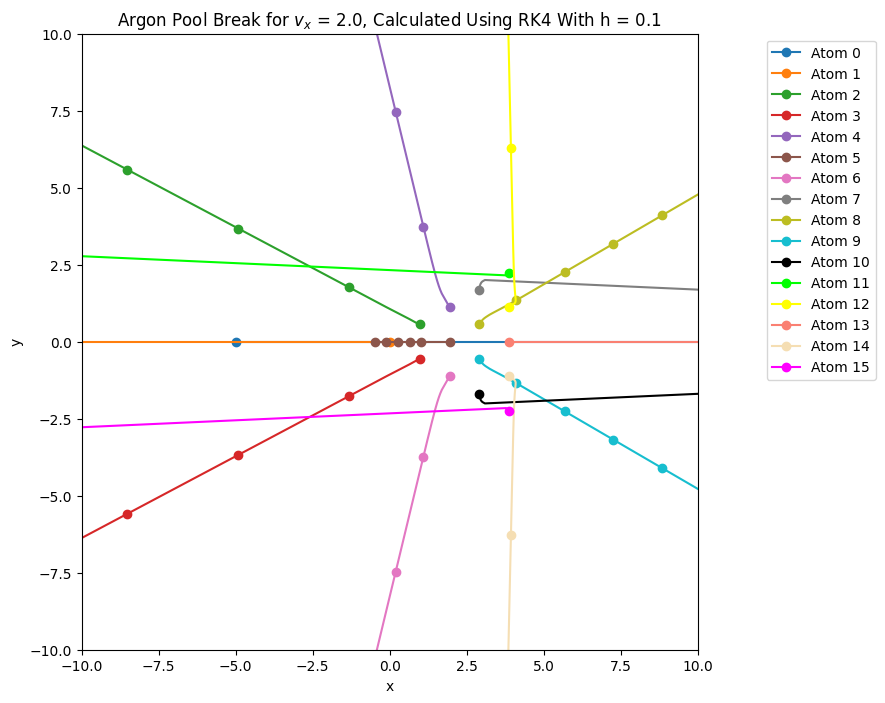

In [8]:
cball2 = Particle(1, [-5.0, 0.0, 0.0], [2.0, 0.0, 0.0])
pool2 = [cball2, b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, b14, b15]

fig, axpool2 = plt.subplots(1, 1, figsize = (8, 8))
xyplotting(pool2, pooltime, alj, rk4, axpool2, 10)
axpool2.set_xlim(-10, 10)
axpool2.set_ylim(-10, 10)
axpool2.set_box_aspect(1)
axpool2.set_title("Argon Pool Break for $v_x$ = 2.0, Calculated Using RK4 With h = 0.1")

Repeat for case 3 (Hard Break) :  $v_x = 5$

Text(0.5, 1.0, 'Argon Pool Break for $v_x$ = 5.0, Calculated Using RK4 With h = 0.1')

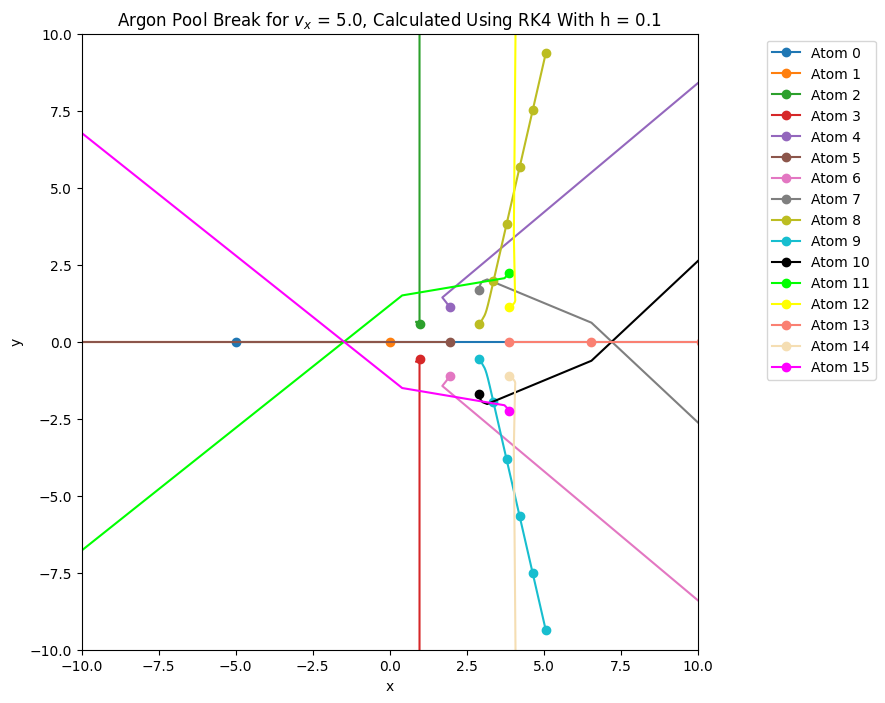

In [9]:
cball3 = Particle(1, [-5.0, 0.0, 0.0], [5.0, 0.0, 0.0])
pool3 = [cball3, b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, b14, b15]

fig, axpool3 = plt.subplots(1, 1, figsize = (8, 8))
xyplotting(pool3, pooltime, alj, rk4, axpool3, 10)
axpool3.set_xlim(-10, 10)
axpool3.set_ylim(-10, 10)
axpool3.set_box_aspect(1)
axpool3.set_title("Argon Pool Break for $v_x$ = 5.0, Calculated Using RK4 With h = 0.1")

In the markdown cell below, discuss what is happening from a _physical_ perspective in each of the 3 cases, and why the behaviour is qualitatively different for each case.

Suppose that instead we had modelled the physics of hard billiard balls (that you may assume have elastic collisions). Apart from the obvious difference of spatial scales and time scales, discuss how the behaviour of the balls would be different from that of argon atoms after the "break" in each of the cases that you have investigated in part d).

In the $v_x$ = 0.2 case, most of the atoms in the rack are interacting with each other before the "cue" atom gets close. Therefore most of the interactions take place within the rack, and all the rack atoms shoot out away from the rack.

In the $v_x$ = 2.0 case, the "cue" atom reaches the top of the rack, keeping the middle (atom 5) atom closer to the center for longer. This allows for the back row particles to shoot out more in the positive-x direction instead of just outwards, as there is the force from the middle atom.

In the $v_x$ = 5.0 case, the "cue" atom has forced its way through the rack. This has caused the outer atoms to speed away given how close the particles got, and the extra atom as added force. Furthermore, this is not physically possible, as the cue atom had to phase through the others, which does not make sence. Extra time steps would limit this error. 

In normal pool, the balls would not interact unless physically touched, meaning the rack would stay together until the cue ball arrives, and would continue in straight lines until hit otherwise. 